### Sobel Edge Detection using OpenCV

This code block will perform Sobel edge detection on an input image. Make sure you replace `'path/to/your/image.jpg'` with the actual path to your image file. If you don't have an image, you can upload one to your Colab environment or use a sample image URL.

**Steps:**
1.  **Load the image**: Reads the image from the specified path.
2.  **Convert to grayscale**: Sobel operator works best on grayscale images.
3.  **Apply Sobel operators**: Computes gradients in the X and Y directions separately.
4.  **Combine gradients**: Merges the X and Y gradients to get the overall edge magnitude.
5.  **Display results**: Shows the original, grayscale, and edge-detected images.

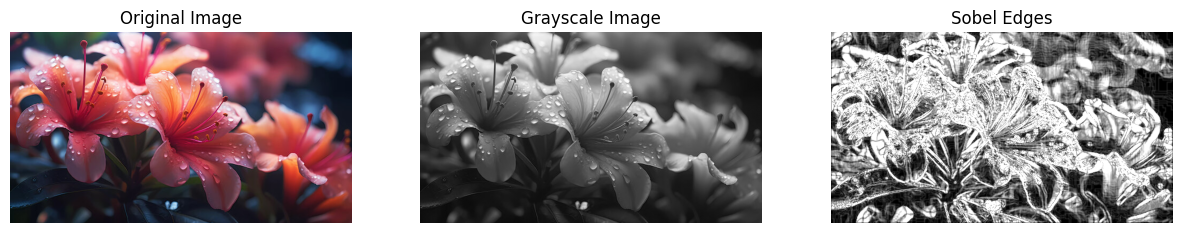

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# --- 1. Load the image ---
# Replace 'path/to/your/image.jpg' with the actual path to your image file.
# If you're running this in Google Colab, you might need to upload an image
# or use cv2.imread(cv2.samples.findFile('starry_night.jpg')) for a sample if available.
# For demonstration, let's try to fetch a sample image if possible, or use a placeholder.

# Example of loading a default sample image from OpenCV if available
# You might need to manually upload an image to your Colab session's files (left sidebar)
# or download one from a URL.

# If you have an image uploaded to your Colab environment, use its path:
image_path = 'Flower.jpg' # <<< CHANGE THIS TO YOUR IMAGE PATH

# Or, if you want to download a sample image (e.g., from an online source):
# import requests
# from io import BytesIO
# image_url = "https://i.stack.imgur.com/r62Kq.jpg" # Example image URL
# response = requests.get(image_url)
# img_array = np.array(bytearray(response.content), dtype=np.uint8)
# img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# For now, let's assume a placeholder and handle potential errors
try:
    img = cv2.imread(image_path)
    if img is None:
        # Fallback if image not found at path, try a common sample name or inform user
        print(f"Warning: Image not found at '{image_path}'. Trying a default sample image (if available).")
        # Attempt to load a sample image from OpenCV's samples directory if it's there
        # This line might not work directly in Colab without specific setup or file uploads
        # img = cv2.imread(cv2.samples.findFile('sudoku.png'))

        # For Colab, it's more reliable to instruct the user to upload or use a direct URL download.
        # Let's create a dummy image for demonstration if no image is found
        print("Creating a dummy image for demonstration since no image was loaded.")
        img = np.zeros((200, 300, 3), dtype=np.uint8)
        cv2.putText(img, 'No Image Loaded!', (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)


except Exception as e:
    print(f"Error loading image: {e}")
    print("Creating a dummy image for demonstration.")
    img = np.zeros((200, 300, 3), dtype=np.uint8)
    cv2.putText(img, 'Error Loading Image!', (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)


# Check if image was successfully loaded/created
if img is None:
    print("Fatal Error: Could not load or create any image. Please check your image path.")
else:
    # --- 2. Convert to grayscale ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 3. Apply Sobel operators ---
    # Sobel X-direction
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5) # dx=1, dy=0
    # Sobel Y-direction
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5) # dx=0, dy=1

    # --- 4. Combine gradients ---
    # Calculate the absolute value of the gradients
    abs_sobelx = cv2.convertScaleAbs(sobelx)
    abs_sobely = cv2.convertScaleAbs(sobely)

    # Combine the x and y gradient components
    sobel_combined = cv2.addWeighted(abs_sobelx, 0.5, abs_sobely, 0.5, 0)

    # --- 5. Display results ---
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gray, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(sobel_combined, cmap='gray')
    plt.title('Sobel Edges')
    plt.axis('off')

    plt.show()
